In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import model_qagent as model

# Exploration

In [3]:
default_rewards = {i: 1 for i in range(100)}
default_rewards[0] = -10

In [ ]:
ex = model.Memory(100, 5, default_rewards, mean_s=0, trauma=(0, -10))
print(ex.graph.nodes())

In [ ]:
ex.visualize("Example Memory Network", min_strength=0.1)

In [ ]:
ex.add_memories(10)
ex.visualize()

In [ ]:
environment = model.Memory(100, 5, default_rewards, trauma=(0, 10))
agent = model.QAgent(environment)
test = model.Simulator(agent, environment)
test.run(100, 100, time=5, print_message=True, delta=20, a=0.5)
for trial in test.record:
    print(len(trial))
test.network.visualize(min_strength=1)

In [ ]:
data = test.network.group_activation()
xs = [0, 0, 0, 0] + list(data.keys())[:101]
ys = list(data.values())
sns.relplot(x=xs, y=ys, kind="scatter")
plt.show()

# Experiment 1: Agent Parameters

- alpha
- gamma
- temperature

In [ ]:
def exp_1(opt, params, n, rep=10):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        rep_avg = []
        rep_final = []
        for _ in range(rep):
            if opt == "alpha":
                agent = model.Agent(alpha=p)
            elif opt == "gamma":
                agent = model.Agent(gamma=p)
            elif opt == "temp":
                agent = model.Agent(temp=p)
            environment = model.Memory(100, 5, default_rewards, trauma=(0, 1))
            test = model.Simulator(agent, environment)
            test.run(n, 100, time=5, delta=20, a=10)
            retrieval_length = [len(trial) for trial in test.record]
            rep_avg.append(np.mean(retrieval_length))
            rep_final.append(retrieval_length[-1])
        avg_retrieval.append(np.mean(rep_avg))
        final_retrieval.append(np.mean(rep_final))
    return avg_retrieval, final_retrieval

fig, axs = plt.subplots(3, 2, sharey=True)
alphas = [n / 100 for n in range(1, 21)]
gammas = [n / 100 for n in range(80, 100)]
temps = [n / 100 for n in range(1, 21)]
ax_count = 0
for opt, params in {"alpha": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = exp_1(opt, params, 50, rep=10)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()

In [ ]:
def exp_1(opt, params, n, rep=10):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        rep_avg = []
        rep_final = []
        for _ in range(rep):
            environment = model.Memory(100, 5, default_rewards, trauma=(0, 1))
            if opt == "alpha":
                agent = model.QAgent(environment, alpha=p)
            elif opt == "gamma":
                agent = model.QAgent(environment, gamma=p)
            elif opt == "temp":
                agent = model.QAgent(environment, temp=p)
            test = model.Simulator(agent, environment)
            test.run(n, 100, time=50, delta=20, a=1)
            retrieval_length = [len(trial) for trial in test.record]
            rep_avg.append(np.mean(retrieval_length))
            rep_final.append(retrieval_length[-1])
        avg_retrieval.append(np.mean(rep_avg))
        final_retrieval.append(np.mean(rep_final))
    return avg_retrieval, final_retrieval

fig, axs = plt.subplots(3, 2, sharey=True)
alphas = [n / 100 for n in range(1, 21)]
gammas = [n / 100 for n in range(80, 100)]
temps = [n / 100 for n in range(1, 21)]
ax_count = 0
for opt, params in {"alpha": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = exp_1(opt, params, 50, rep=1)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()

# Experiment 2: Environment Parameters

- Number of memories
- Number of groups
- Connectivity
- Rewards
- Trauma Activation
- Decay
- Delta (Additional Memories Presented)

In [9]:
def exp_2(n, groups, max_length, runs=100, time=0.1, rewards=None, t_a=1):
    if rewards is None:
        rewards = {i: 1 for i in range(n)}
        rewards[0] = -10
    environment = model.Memory(n, groups, rewards, trauma=(0, t_a))
    agent = model.Agent()
    test = model.Simulator(agent, environment)
    test.run(runs, max_length, time=time, delta=20, a=1)
    retrieval_length = [len(trial) for trial in test.record]
    return retrieval_length

In [10]:
def qexp_2(n, groups, max_length, runs=100, time=0.1, rewards=None, t_a=1):
    if rewards is None:
        rewards = {i: 1 for i in range(n)}
        rewards[0] = -10
    environment = model.Memory(n, groups, rewards, trauma=(0, t_a))
    agent = model.QAgent(environment)
    test = model.Simulator(agent, environment)
    test.run(runs, max_length, time=time, delta=20, a=1)
    retrieval_length = [len(trial) for trial in test.record]
    return retrieval_length

In [ ]:
data = []
groups = 10
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying numbers of memories (number of groups constant)")
plt.show()

In [ ]:
data = []
groups = 10
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    for _ in range(i):
        rewards[_] = -10
    lengths = qexp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying numbers of memories (number of groups constant)")
plt.show()

In [ ]:
data = []
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    groups = n // 10
    for _ in range(i):
        rewards[_] = -10
    lengths = exp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying number of memories (group size constant)")
plt.show()

In [ ]:
data = []
for i, n in enumerate([50, 100, 150, 200, 250]):
    rewards = {i: 1 for i in range(n)}
    groups = n // 10
    for _ in range(i):
        rewards[_] = -10
    lengths = qexp_2(n, groups, max_length=n - 1, rewards=rewards)
    for length in lengths:
        data.append({"n": n, "value": length / n})
sns.catplot(data=pd.DataFrame(data), x="n", y="value", kind="bar")
plt.title(f"Percent of total memories retrieved for varying number of memories (group size constant)")
plt.show()

In [ ]:
data = []
n = 100
groups = 10
for t in [0.1, 1, 10, 100]:
    lengths = exp_2(n, groups, max_length=n - 1, time=t)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"time": t, "type": "average", "value": avg / n})
    data.append({"time": t, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="time", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
n = 100
groups = 10
for t in [0.1, 1, 10, 100]:
    lengths = qexp_2(n, groups, max_length=n - 1, time=t)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"time": t, "type": "average", "value": avg / n})
    data.append({"time": t, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="time", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
groups = 10
n = 100
rewards = {i: 1 for i in range(n)}
rewards1 = rewards.copy()
rewards2 = rewards.copy()
rewards3 = rewards.copy()
rewards4 = rewards.copy()
rewards1[0] = -10
rewards2[0] = -100
for i in range(5):
    rewards3[i] = -10
    rewards4[i] = -100
for r, name in zip([rewards1, rewards2, rewards3, rewards4], ["r1", "r2", "r3", "r4"]):
    lengths = exp_2(n, groups, max_length=n - 1, time=0.1, rewards=r)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"reward": name, "type": "average", "value": avg / n})
    data.append({"reward": name, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="reward", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

In [ ]:
data = []
groups = 10
n = 100
rewards = {i: 1 for i in range(n)}
rewards1 = rewards.copy()
rewards2 = rewards.copy()
rewards3 = rewards.copy()
rewards4 = rewards.copy()
rewards1[0] = -10
rewards2[0] = -100
for i in range(5):
    rewards3[i] = -10
    rewards4[i] = -100
for r, name in zip([rewards1, rewards2, rewards3, rewards4], ["r1", "r2", "r3", "r4"]):
    lengths = qexp_2(n, groups, max_length=n - 1, time=0.1, rewards=r)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"reward": name, "type": "average", "value": avg / n})
    data.append({"reward": name, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="reward", y="value", hue="type", kind="bar")
plt.title(f"Percent of total memories retrieved for {n} memories and {groups} groups")
plt.show()

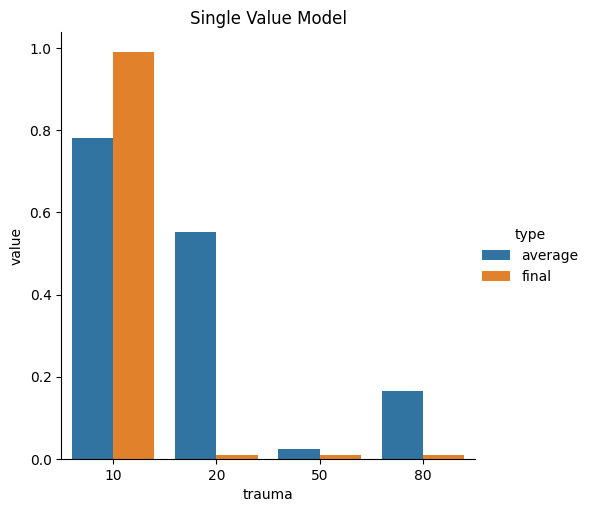

In [16]:
data = []
n = 100
groups = 10
for t_a in [10, 20, 50, 80]:
    lengths = exp_2(n, groups, max_length=n - 1, t_a=t_a)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"trauma": t_a, "type": "average", "value": avg / n})
    data.append({"trauma": t_a, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="trauma", y="value", hue="type", kind="bar")
plt.title(f"Single Value Model")
plt.show()

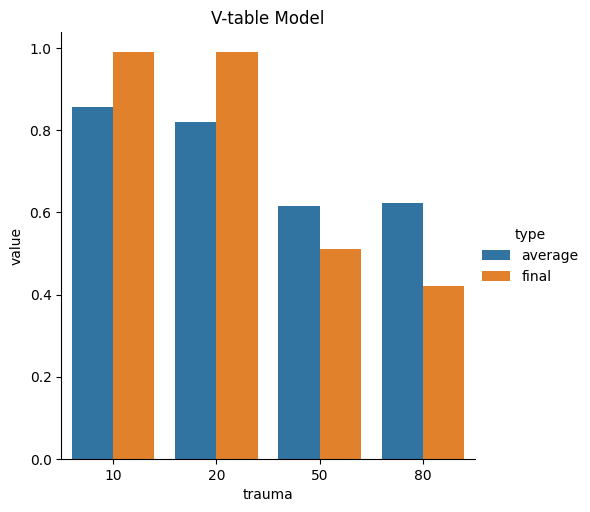

In [17]:
data = []
n = 100
groups = 10
for t_a in [10, 20, 50, 80]:
    lengths = qexp_2(n, groups, max_length=n - 1, t_a=t_a)
    avg = np.mean(lengths)
    final = lengths[-1]
    data.append({"trauma": t_a, "type": "average", "value": avg / n})
    data.append({"trauma": t_a, "type": "final", "value": final / n})
sns.catplot(data=pd.DataFrame(data), x="trauma", y="value", hue="type", kind="bar")
plt.title(f"V-table Model")
plt.show()

Trauma encountered in 29/100 retrievals (29.0%)
56
34
20
2
5
2
17
40
20
17
28
17
36
43
40
4
50
25
19
20
33
61
7
60
75
20
60
2
20
20
40
43
100
94
74
60
79
90
54
39
4
100
1
21
100
100
88
100
47
94
64
22
100
96
45
53
52
100
95
88
71
60
100
100
23
100
100
100
72
76
100
100
100
100
78
38
100
100
100
93
100
43
68
51
3
100
26
100
48
100
100
100
100
100
100
70
73
89
100
100


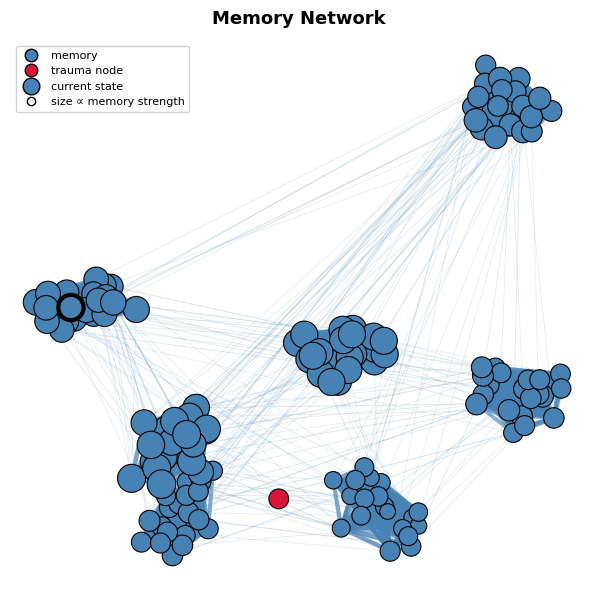

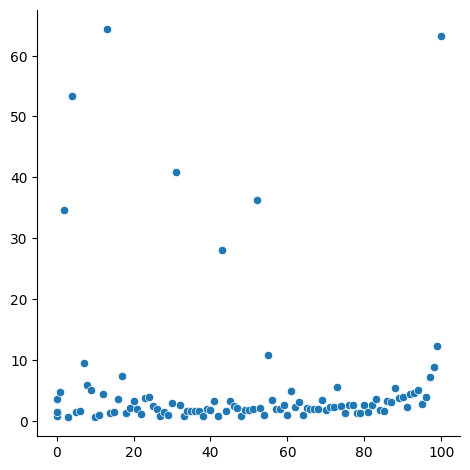

In [6]:
trauma_rewards = default_rewards.copy()
trauma_rewards[0] = -100
environment = model.Memory(100, 5, trauma_rewards, thres=0, in_group=1, trauma=(0, 10))
agent = model.QAgent(environment)
test = model.Simulator(agent, environment)
test.run(100, 100, time=10, print_message=True, delta=20, a=0.1)
for trial in test.record:
    print(len(trial))
test.network.visualize(min_strength=1)
data = test.network.group_activation()
xs = [0, 0, 0, 0] + list(data.keys())[:101]
ys = list(data.values())
sns.relplot(x=xs, y=ys, kind="scatter")
plt.show()

Trauma encountered in 15/50 retrievals (30.0%)
Trauma encountered in 14/50 retrievals (28.0%)
Trauma encountered in 6/50 retrievals (12.0%)
Trauma encountered in 15/50 retrievals (30.0%)
Trauma encountered in 11/50 retrievals (22.0%)
Trauma encountered in 13/50 retrievals (26.0%)
Trauma encountered in 11/50 retrievals (22.0%)
Trauma encountered in 13/50 retrievals (26.0%)
Trauma encountered in 17/50 retrievals (34.0%)
Trauma encountered in 17/50 retrievals (34.0%)
Trauma encountered in 17/50 retrievals (34.0%)
Trauma encountered in 12/50 retrievals (24.0%)
Trauma encountered in 10/50 retrievals (20.0%)
Trauma encountered in 6/50 retrievals (12.0%)
Trauma encountered in 8/50 retrievals (16.0%)
Trauma encountered in 5/50 retrievals (10.0%)
Trauma encountered in 11/50 retrievals (22.0%)
Trauma encountered in 12/50 retrievals (24.0%)
Trauma encountered in 7/50 retrievals (14.0%)
Trauma encountered in 16/50 retrievals (32.0%)
Trauma encountered in 10/50 retrievals (20.0%)
Trauma encountered

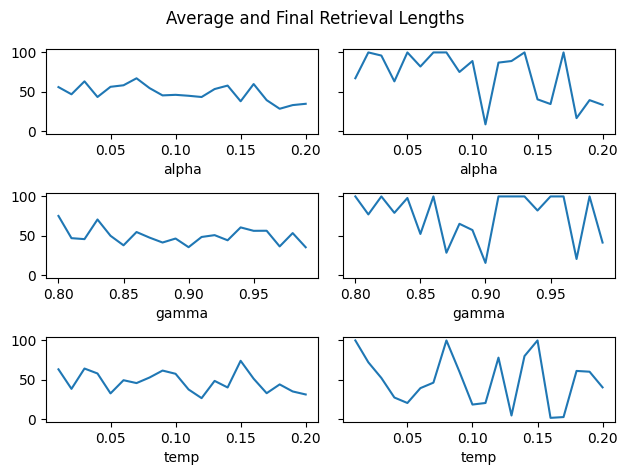

In [8]:
def exp_1(opt, params, runs, rep=10):
    avg_retrieval = []
    final_retrieval = []
    for p in params:
        rep_avg = []
        rep_final = []
        for _ in range(rep):
            environment = model.Memory(100, 5, trauma_rewards, thres=0, in_group=1, trauma=(0, 10))
            if opt == "alpha":
                agent = model.QAgent(environment, alpha=p)
            elif opt == "gamma":
                agent = model.QAgent(environment, gamma=p)
            elif opt == "temp":
                agent = model.QAgent(environment, temp=p)
            test = model.Simulator(agent, environment)
            test.run(runs, 100, time=10, print_message=True, delta=20, a=0.1)
            retrieval_length = [len(trial) for trial in test.record]
            rep_avg.append(np.mean(retrieval_length))
            rep_final.append(retrieval_length[-1])
        avg_retrieval.append(np.mean(rep_avg))
        final_retrieval.append(np.mean(rep_final))
    return avg_retrieval, final_retrieval

fig, axs = plt.subplots(3, 2, sharey=True)
alphas = [n / 100 for n in range(1, 21)]
gammas = [n / 100 for n in range(80, 100)]
temps = [n / 100 for n in range(1, 21)]
ax_count = 0
for opt, params in {"alpha": alphas, "gamma": gammas, "temp": temps}.items():
    avg_retrieval, final_retrieval = exp_1(opt, params, 50, rep=1)
    sns.lineplot(x=params, y=avg_retrieval, ax=axs[ax_count][0])
    sns.lineplot(x=params, y=final_retrieval, ax=axs[ax_count][1])
    axs[ax_count][0].set_xlabel(opt)
    axs[ax_count][1].set_xlabel(opt)
    ax_count += 1
fig.suptitle("Average and Final Retrieval Lengths")
plt.tight_layout()
plt.show()